# BC Detection Benchmark Analysis 

In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [ ]:
df = pd.read_csv(Path("data/preliminary-results-aggregated.csv"))
df

,tool,temperature,round,thinking,scope,tp,fp,fn,precision,recall,accuracy,f1
0,roseau,-1.0,1,False,breaking,191,3,1,0.9845,0.9948,0.9871,0.9896
1,roseau,-1.0,1,False,source,171,21,0,0.8906,1.0000,0.9323,0.9421
2,roseau,-1.0,1,False,binary,105,7,1,0.9375,0.9906,0.9742,0.9633
3,GPT52,0.0,1,False,breaking,161,27,31,0.8564,0.8385,0.8129,0.8474
4,GPT52,0.0,1,False,source,136,40,35,0.7727,0.7953,0.7581,0.7839
5,GPT52,0.0,1,False,binary,105,55,1,0.6563,0.9906,0.8194,0.7895
6,claude-sonnet-46,0.0,1,False,breaking,183,11,9,0.9433,0.9531,0.9355,0.9482
7,claude-sonnet-46,0.0,1,False,source,163,23,8,0.8763,0.9532,0.9000,0.9132
8,claude-sonnet-46,0.0,1,False,binary,105,18,1,0.8537,0.9906,0.9387,0.9170
9,GPT52,0.3,1,False,breaking,161,27,31,0.8564,0.8385,0.8129,0.8474


In [3]:
df_aggregated = df.copy()

df_aggregated = df_aggregated[df_aggregated["temperature"] == 0.3]
df_aggregated = df_aggregated[df_aggregated["thinking"] == False]

df_aggregated = df_aggregated.groupby(["tool", "scope"]).agg({
    "tp": "mean",
    "fp": "mean",
    "fn": "mean",
    "precision": "mean",
    "recall": "mean",
    "accuracy": "mean",
    "f1": "mean"
}).reset_index()

df_aggregated["type"] = "temp=0.3"

df_aggregated

,tool,scope,tp,fp,fn,precision,recall,accuracy,f1,type
0,GPT52,binary,104.0,60.666667,2.0,0.631567,0.981100,0.797833,0.768500,temp=0.3
1,GPT52,breaking,163.0,28.000000,29.0,0.853533,0.848967,0.816133,0.851167,temp=0.3
2,GPT52,source,139.0,40.000000,32.0,0.776567,0.812867,0.767733,0.794300,temp=0.3
3,claude-sonnet-46,binary,105.0,17.333333,1.0,0.858433,0.990600,0.940867,0.919733,temp=0.3
4,claude-sonnet-46,breaking,180.0,11.333333,12.0,0.940767,0.937500,0.924733,0.939100,temp=0.3
5,claude-sonnet-46,source,159.0,22.666667,12.0,0.875233,0.929833,0.888167,0.901700,temp=0.3


In [ ]:
columns = ["tool", "scope", "tp", "fp", "fn", "precision", "recall", "accuracy", "f1"]

df_temp_0 = df[df["temperature"] == 0][columns]
df_temp_0["type"] = "temp=0.0"

df_temp_thinking = df[(df["temperature"] == -1) & (df["thinking"] == True)][columns]
df_temp_thinking["type"] = "thinking"

df_temp_static = df[(df["temperature"] == -1) & (df["thinking"] == False)][columns]
df_temp_static["type"] = "static"

df_aggregated = pd.concat( \
    [df_aggregated, df_temp_0, df_temp_thinking, df_temp_static], \
    ignore_index=True) 
df_aggregated

,tool,scope,tp,fp,fn,precision,recall,accuracy,f1,type
0,GPT52,binary,104.0,60.666667,2.0,0.631567,0.981100,0.797833,0.768500,temp=0.3
1,GPT52,breaking,163.0,28.000000,29.0,0.853533,0.848967,0.816133,0.851167,temp=0.3
2,GPT52,source,139.0,40.000000,32.0,0.776567,0.812867,0.767733,0.794300,temp=0.3
3,claude-sonnet-46,binary,105.0,17.333333,1.0,0.858433,0.990600,0.940867,0.919733,temp=0.3
4,claude-sonnet-46,breaking,180.0,11.333333,12.0,0.940767,0.937500,0.924733,0.939100,temp=0.3
5,claude-sonnet-46,source,159.0,22.666667,12.0,0.875233,0.929833,0.888167,0.901700,temp=0.3
6,GPT52,breaking,161.0,27.000000,31.0,0.856400,0.838500,0.812900,0.847400,temp=0.0
7,GPT52,source,136.0,40.000000,35.0,0.772700,0.795300,0.758100,0.783900,temp=0.0
8,GPT52,binary,105.0,55.000000,1.0,0.656300,0.990600,0.819400,0.789500,temp=0.0
9,claude-sonnet-46,breaking,183.0,11.000000,9.0,0.943300,0.953100,0.935500,0.948200,temp=0.0


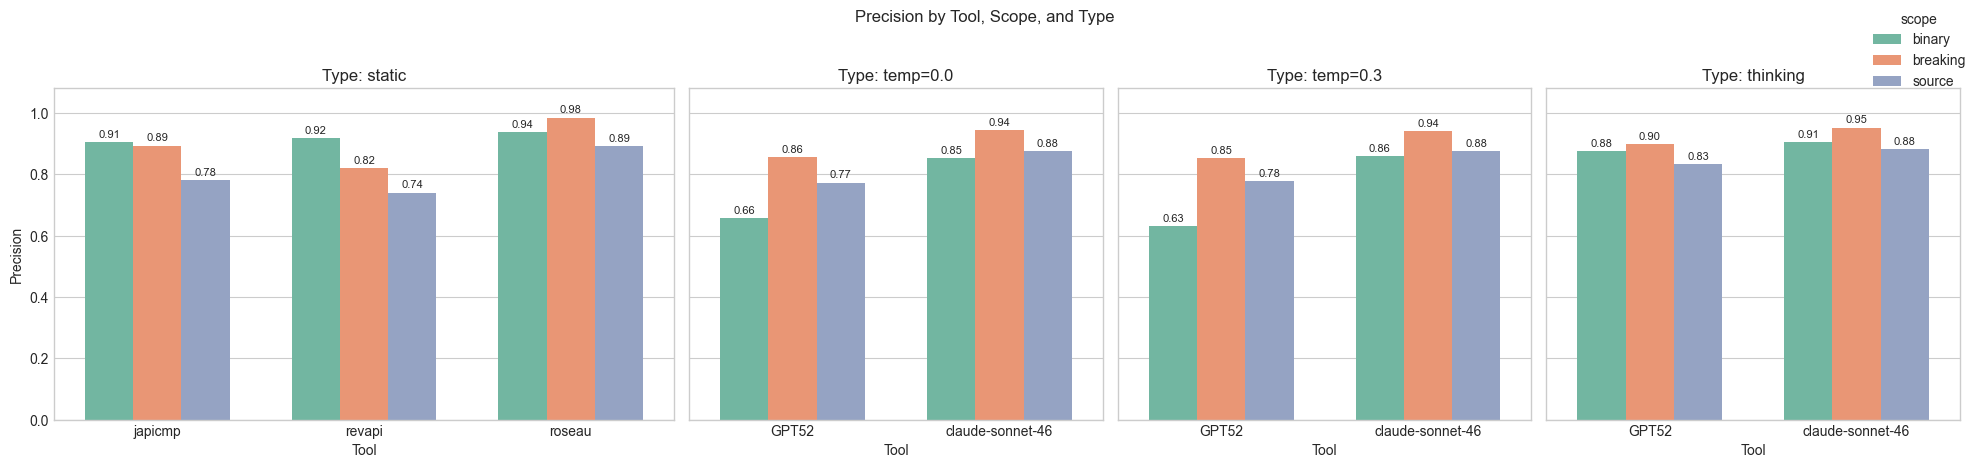

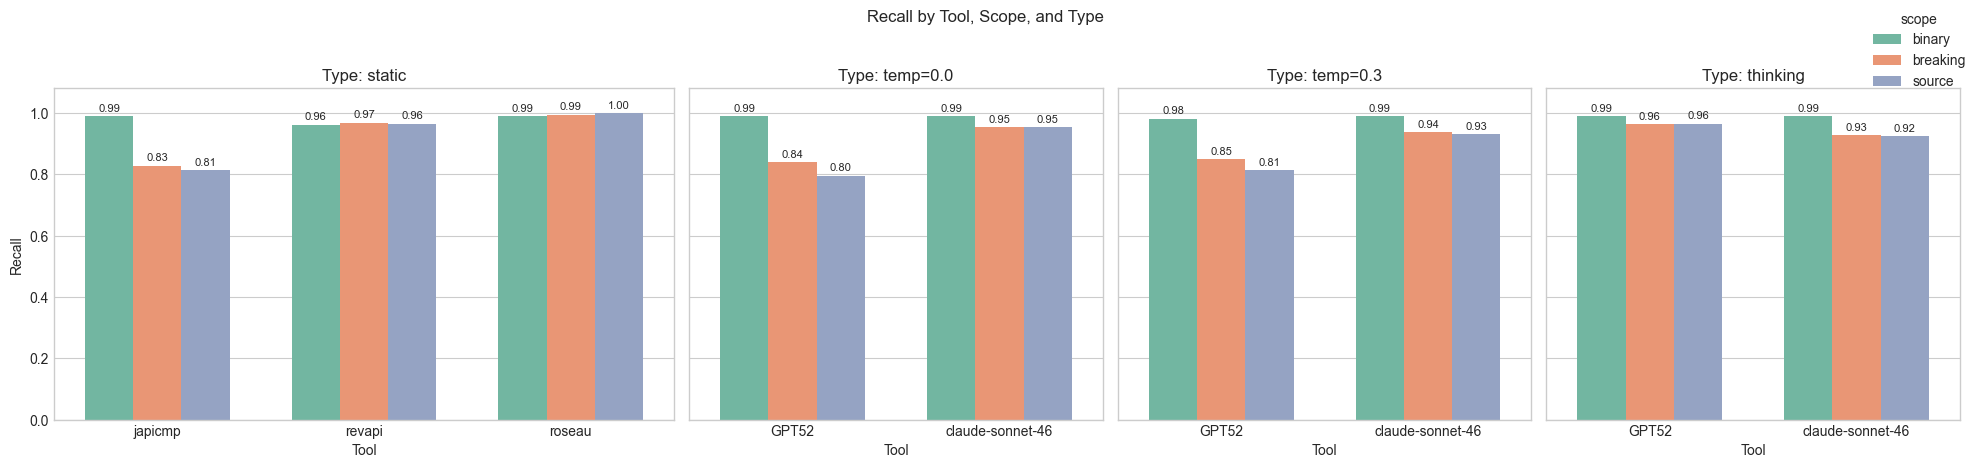

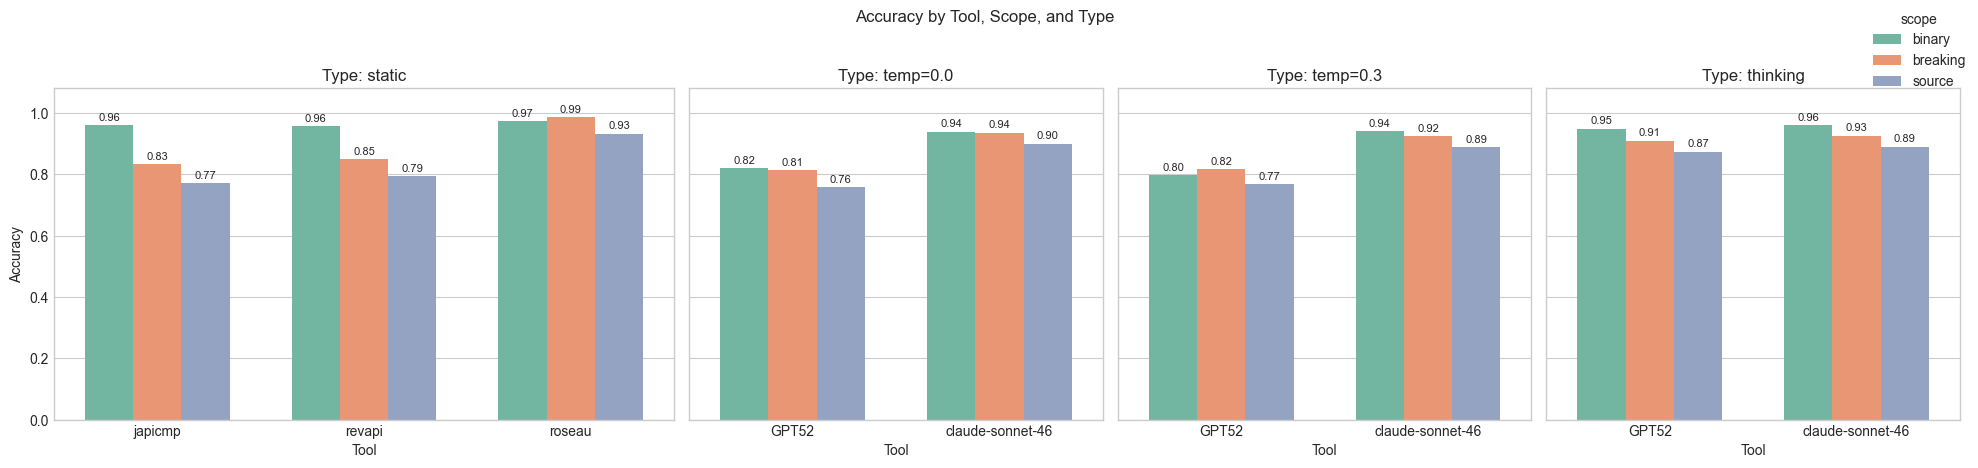

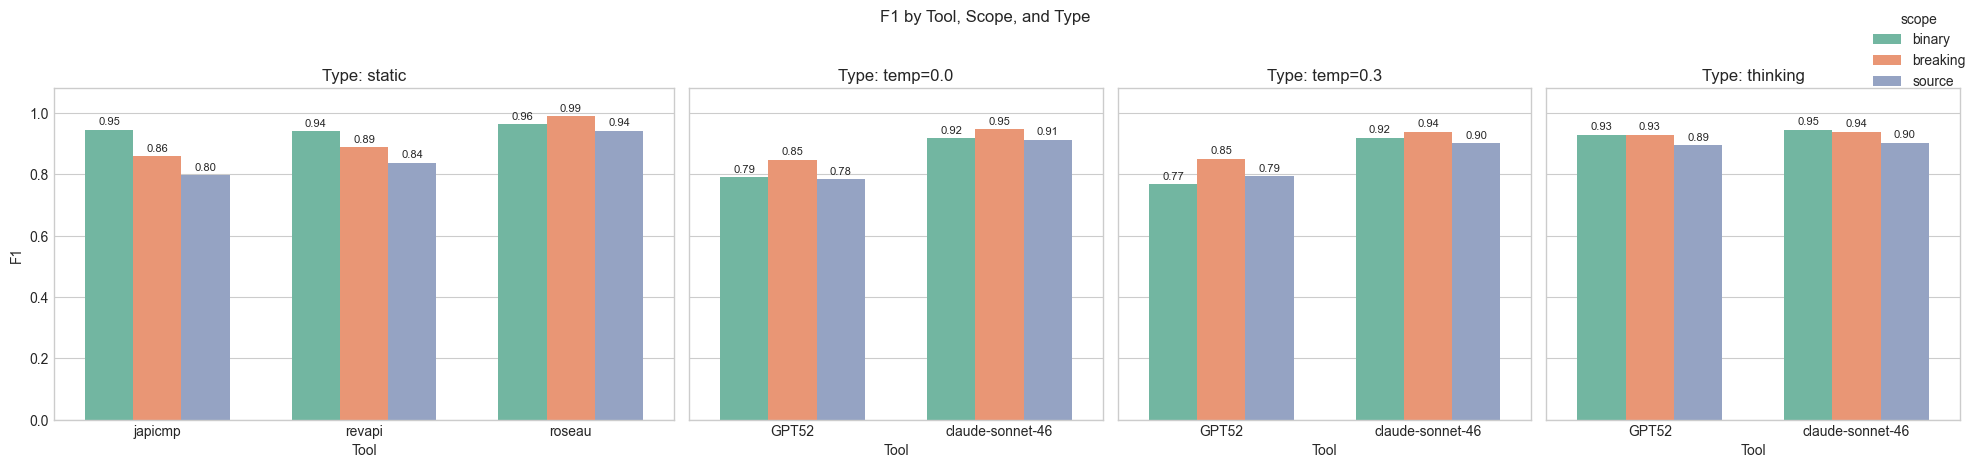

In [ ]:
metrics = ["precision", "recall", "accuracy", "f1"]
type_order = sorted(df_aggregated["type"].dropna().unique())
scope_order = sorted(df_aggregated["scope"].dropna().unique())

for metric in metrics:
    plot_data = df_aggregated.dropna(subset=[metric]).copy()
    tools_per_type = {
        t: sorted(plot_data.loc[plot_data["type"] == t, "tool"].dropna().unique())
        for t in type_order
    }
    width_ratios = [max(len(tools_per_type[t]), 1) for t in type_order]

    fig, axes = plt.subplots(
        1,
        len(type_order),
        figsize=(2.2 * sum(width_ratios), 4.5),
        sharey=True,
        gridspec_kw={"width_ratios": width_ratios},
    )

    if len(type_order) == 1:
        axes = [axes]

    for ax, t in zip(axes, type_order):
        type_data = plot_data[plot_data["type"] == t]
        tool_order = tools_per_type[t]

        sns.barplot(
            data=type_data,
            x="tool",
            y=metric,
            hue="scope",
            hue_order=scope_order,
            order=tool_order,
            width=0.7,
            palette="Set2",
            ax=ax,
        )

        for container in ax.containers:
            labels = ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
            for txt in labels:
                txt.set_clip_on(False)

        ax.set_title(f"Type: {t}")
        ax.set_xlabel("Tool")
        ax.set_ylim(0, 1.08)

    axes[0].set_ylabel(metric.capitalize())
    for ax in axes[1:]:
        ax.set_ylabel("")

    handles, labels = axes[0].get_legend_handles_labels()
    for ax in axes:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    fig.legend(handles, labels, title="scope", loc="upper right")

    fig.suptitle(f"{metric.capitalize()} by Tool, Scope, and Type", y=1.03)
    fig.tight_layout()
    plt.show()


In [ ]:
metrics = ["accuracy", "precision", "recall", "f1"]

tool_aliases = {
    "GPT52": ["gpt52", "gpt 5.2"],
    "claude-sonnet-46": ["claude-sonnet-46", "claude sonnet 4.6"],
}

df_cmp = df.copy()
df_cmp["tool_norm"] = df_cmp["tool"].astype(str).str.strip().str.lower()

allowed_norms = {alias for aliases in tool_aliases.values() for alias in aliases}
df_cmp = df_cmp[df_cmp["tool_norm"].isin(allowed_norms)].copy()

alias_to_tool = {
    alias: canonical
    for canonical, aliases in tool_aliases.items()
    for alias in aliases
}
df_cmp["tool_label"] = df_cmp["tool_norm"].map(alias_to_tool)
df_cmp["condition"] = np.select(
    [
        (df_cmp["temperature"] == 0.0),
        (df_cmp["temperature"] == 0.3),
        (df_cmp["thinking"] == True),
    ],
    ["temp=0.0", "temp=0.3", "thinking"],
    default=None,
)

df_cmp = df_cmp[df_cmp["condition"].notna()].copy()
condition_order = ["temp=0.0", "temp=0.3", "thinking"]

table_base = (
    df_cmp.groupby(["condition", "scope", "tool_label"], as_index=False)[metrics]
    .mean()
)

for cond in condition_order:
    print(f"\nComparison of GPT52 vs claude-sonnet-46 for {cond}")

    table = (
        table_base[table_base["condition"] == cond]
        .melt(id_vars=["scope", "tool_label"], value_vars=metrics, var_name="metric", value_name="value")
        .pivot_table(index=["scope", "metric"], columns="tool_label", values="value", aggfunc="mean")
        .reindex(columns=["GPT52", "claude-sonnet-46"])
    )

    table["diff (GPT52 - claude-sonnet-46)"] = table["GPT52"] - table["claude-sonnet-46"]
    display(table.round(3))


Comparison of GPT52 vs claude-sonnet-46 for temp=0.0


tool_label          GPT52  claude-sonnet-46  diff (GPT52 - claude-sonnet-46)
scope    metric                                                             
binary   accuracy   0.819             0.939                           -0.119
         f1         0.790             0.917                           -0.128
         precision  0.656             0.854                           -0.197
         recall     0.991             0.991                            0.000
breaking accuracy   0.813             0.936                           -0.123
         f1         0.847             0.948                           -0.101
         precision  0.856             0.943                           -0.087
         recall     0.838             0.953                           -0.115
source   accuracy   0.758             0.900                           -0.142
         f1         0.784             0.913                           -0.129
         precision  0.773             0.876                           -0.104
         recall     0.795             0.953                           -0.158


Comparison of GPT52 vs claude-sonnet-46 for temp=0.3


tool_label          GPT52  claude-sonnet-46  diff (GPT52 - claude-sonnet-46)
scope    metric                                                             
binary   accuracy   0.798             0.941                           -0.143
         f1         0.768             0.920                           -0.151
         precision  0.632             0.858                           -0.227
         recall     0.981             0.991                           -0.010
breaking accuracy   0.816             0.925                           -0.109
         f1         0.851             0.939                           -0.088
         precision  0.854             0.941                           -0.087
         recall     0.849             0.938                           -0.089
source   accuracy   0.768             0.888                           -0.120
         f1         0.794             0.902                           -0.107
         precision  0.777             0.875                           -0.099
         recall     0.813             0.930                           -0.117


Comparison of GPT52 vs claude-sonnet-46 for thinking


tool_label          GPT52  claude-sonnet-46  diff (GPT52 - claude-sonnet-46)
scope    metric                                                             
binary   accuracy   0.948             0.961                           -0.013
         f1         0.929             0.946                           -0.017
         precision  0.875             0.905                           -0.030
         recall     0.991             0.991                            0.000
breaking accuracy   0.910             0.926                           -0.016
         f1         0.930             0.939                           -0.010
         precision  0.898             0.952                           -0.054
         recall     0.964             0.927                            0.036
source   accuracy   0.874             0.890                           -0.016
         f1         0.894             0.903                           -0.009
         precision  0.833             0.883                           -0.049
         recall     0.965             0.924                            0.041

In [ ]:
metrics = ["accuracy", "precision", "recall", "f1"]

tool_aliases = {
    "GPT52": ["gpt52", "gpt 5.2"],
    "claude-sonnet-46": ["claude-sonnet-46", "claude sonnet 4.6"],
    "roseau": ["roseau"],
    "japicmp": ["japicmp"],
    "revapi": ["revapi"],
}

base = df.copy()
base["tool_norm"] = base["tool"].astype(str).str.strip().str.lower()

alias_to_tool = {
    alias: canonical
    for canonical, aliases in tool_aliases.items()
    for alias in aliases
}
allowed_norms = set(alias_to_tool.keys())

base = base[base["tool_norm"].isin(allowed_norms)].copy()
base["tool_label"] = base["tool_norm"].map(alias_to_tool)

parts = []
for condition, mask in [
    ("temp_0", base["temperature"] == 0),
    ("temp_0.3", base["temperature"] == 0.3),
    ("thinking", base["thinking"] == True),
    ("static", (base["temperature"] == -1) & (base["thinking"] == False)),
]:
    subset = base[mask].copy()
    if subset.empty:
        continue

    agg = (
        subset.groupby(["tool_label", "scope"], as_index=False)[metrics]
        .mean()
        .melt(id_vars=["tool_label", "scope"], value_vars=metrics, var_name="metric", value_name="value")
    )
    agg["condition"] = condition
    parts.append(agg)

merged_long = pd.concat(parts, ignore_index=True)

merged_comparison = (
    merged_long
    .assign(col=lambda x: x["tool_label"] + "_" + x["condition"])
    .pivot_table(index=["scope", "metric"], columns="col", values="value", aggfunc="mean")
)

ordered_cols = [
    "roseau_static",
    "japicmp_static",
    "revapi_static",
    "GPT52_temp_0",
    "GPT52_temp_0.3",
    "GPT52_thinking",
    "claude-sonnet-46_temp_0",
    "claude-sonnet-46_temp_0.3",
    "claude-sonnet-46_thinking",
]
ordered_cols = [c for c in ordered_cols if c in merged_comparison.columns]
merged_comparison = merged_comparison.reindex(columns=ordered_cols).round(3)

def highlight_winners_and_losers(row):
    valid = row.dropna()
    if valid.empty:
        return ["" for _ in row]

    max_val = valid.max()
    min_val = valid.min()

    styles = []
    for v in row:
        if pd.isna(v):
            styles.append("")
        elif v == max_val and v == min_val:
            styles.append("background-color: #fff2cc; font-weight: 700")
        elif v == max_val:
            styles.append("background-color: #d4f8d4; font-weight: 700")
        elif v == min_val:
            styles.append("background-color: #ffd6d6; font-weight: 700")
        else:
            styles.append("")
    return styles

styled_comparison = merged_comparison.style.apply(highlight_winners_and_losers, axis=1)
styled_comparison

In [ ]:
gpt_claude_cols = [
    "GPT52_temp_0",
    "GPT52_temp_0.3",
    "GPT52_thinking",
    "claude-sonnet-46_temp_0",
    "claude-sonnet-46_temp_0.3",
    "claude-sonnet-46_thinking",
]

gpt_claude_cols = [c for c in gpt_claude_cols if c in merged_comparison.columns]
gpt_claude_comparison = merged_comparison.reindex(columns=gpt_claude_cols).copy()

styled_gpt_claude_comparison = gpt_claude_comparison.style.apply(
    highlight_winners_and_losers,
    axis=1,
)
styled_gpt_claude_comparison

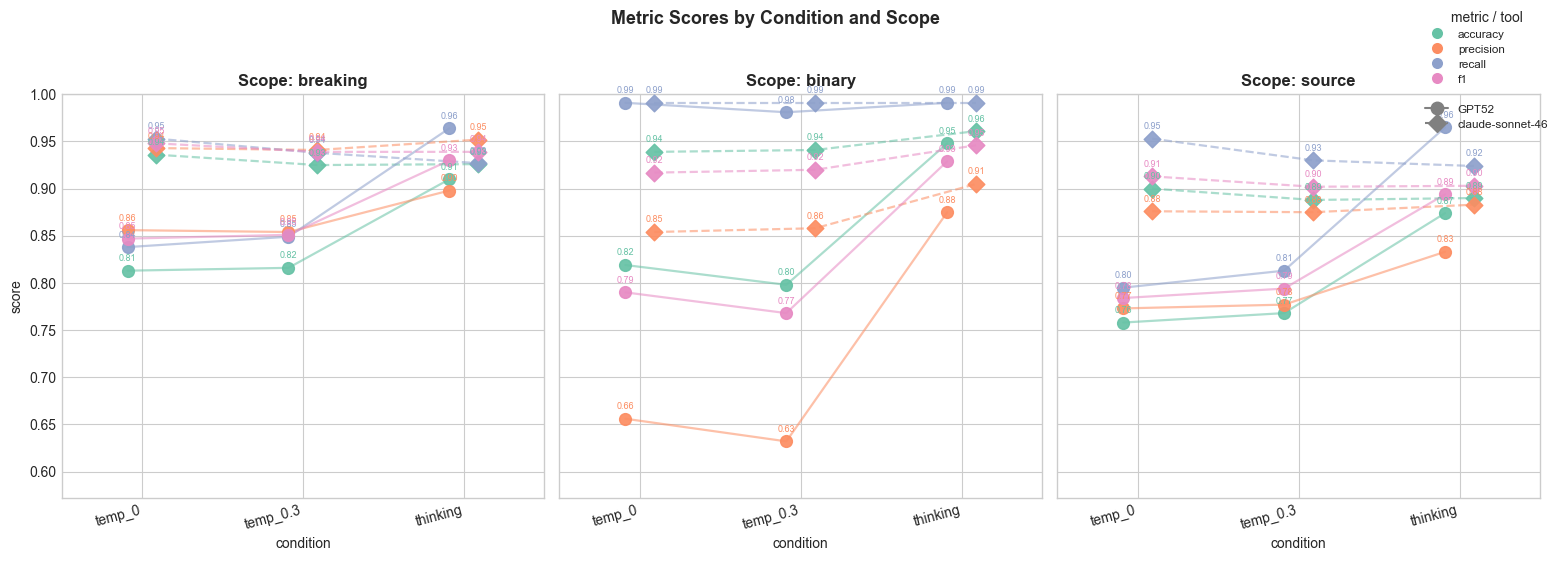

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

if "gpt_claude_comparison" in globals():
    source_df = gpt_claude_comparison.copy()
else:
    source_df = merged_comparison.filter(regex=r"^(GPT52|claude-sonnet-46)_").copy()

long_df = (
    source_df.reset_index()
    .melt(id_vars=["scope", "metric"], var_name="combination", value_name="score")
    .dropna(subset=["score"])
)
long_df[["tool", "condition"]] = long_df["combination"].str.split("_", n=1, expand=True)

condition_order = ["temp_0", "temp_0.3", "thinking"]
condition_pos = {c: i + 1 for i, c in enumerate(condition_order)}
long_df = long_df[long_df["condition"].isin(condition_order)].copy()
long_df["x"] = long_df["condition"].map(condition_pos)


tool_markers = {"GPT52": ("o", -0.09), "claude-sonnet-46": ("D", +0.09)}
tool_linestyles = {"GPT52": "-", "claude-sonnet-46": "--"}

all_scopes = sorted(long_df["scope"].dropna().unique())
scopes = (["breaking"] if "breaking" in all_scopes else []) + [s for s in all_scopes if s != "breaking"]

metrics_order = ["accuracy", "precision", "recall", "f1"]
metrics_in_plot = [m for m in metrics_order if m in set(long_df["metric"])]

palette = sns.color_palette("Set2", n_colors=max(len(metrics_in_plot), 1))
metric_colors = {m: palette[i] for i, m in enumerate(metrics_in_plot)}

all_scores = long_df["score"].dropna()
y_min = max(0.0, all_scores.min() - 0.06)
y_max = min(1.0, all_scores.max() + 0.04)

fig, axes = plt.subplots(
    1, len(scopes),
    figsize=(5.2 * len(scopes), 5.4),
    sharey=True,
    squeeze=False,
)
axes = axes.flatten()

for i, scope in enumerate(scopes):
    ax = axes[i]
    scope_df = long_df[long_df["scope"] == scope]

    for metric in metrics_in_plot:
        for tool, (marker, offset) in tool_markers.items():
            mdf = scope_df[(scope_df["metric"] == metric) & (scope_df["tool"] == tool)].sort_values("x")
            if mdf.empty:
                continue
            xs = mdf["x"].to_numpy() + offset
            ys = mdf["score"].to_numpy()

            ax.plot(xs, ys, color=metric_colors[metric],
                    linestyle=tool_linestyles[tool], linewidth=1.6, alpha=0.55, zorder=2)
            ax.scatter(xs, ys, s=72, alpha=0.92, color=metric_colors[metric],
                       marker=marker, zorder=4)
            for x, y in zip(xs, ys):
                ax.annotate(f"{y:.2f}", (x, y),
                            textcoords="offset points", xytext=(0, 7),
                            ha="center", fontsize=6.5,
                            color=metric_colors[metric], zorder=5)

    ax.set_xticks(list(condition_pos.values()))
    ax.set_xticklabels(condition_order, rotation=15, ha="right")
    ax.set_xlim(0.5, len(condition_order) + 0.5)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"Scope: {scope}", fontweight="bold")
    ax.set_xlabel("condition")
    ax.set_ylabel("score" if i == 0 else "")

metric_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=metric_colors[m], markersize=9, label=m)
    for m in metrics_in_plot
]
tool_handles = [
    Line2D([0], [0], marker="o", color="gray", markerfacecolor="gray", linestyle="-",
           linewidth=1.5, markersize=9, label="GPT52"),
    Line2D([0], [0], marker="D", color="gray", markerfacecolor="gray", linestyle="--",
           linewidth=1.5, markersize=9, label="claude-sonnet-46"),
]
sep = Patch(color="none", label="")
fig.legend(
    handles=metric_handles + [sep] + tool_handles,
    loc="upper right", title="metric / tool",
    labelspacing=0.4, fontsize=8.5,
)

fig.suptitle("Metric Scores by Condition and Scope", y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


,rank,tool,robustness_score,mean_signed_delta,max_abs_delta,n_cells
0,1,claude-sonnet-46,0.00795,-0.006344,0.023367,12
1,2,GPT52,0.01155,-0.001728,0.024733,12


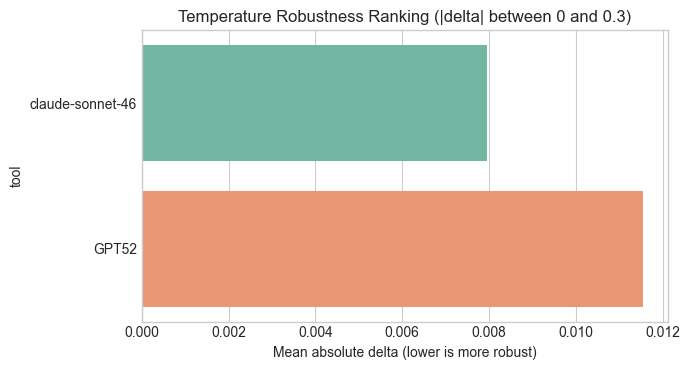

In [ ]:
temp_low = 0
temp_high = 0.3
metrics = ["precision", "recall", "accuracy", "f1"]

base = (
    df[df["temperature"].isin([temp_low, temp_high])][["tool", "scope", "temperature"] + metrics]
    .groupby(["tool", "scope", "temperature"], as_index=False)[metrics]
    .mean()
    .melt(id_vars=["tool", "scope", "temperature"], value_vars=metrics, var_name="metric", value_name="value")
)

pivoted = (
    base.pivot_table(
        index=["tool", "scope", "metric"],
        columns="temperature",
        values="value",
        aggfunc="mean",
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

pivoted["delta"] = pivoted.get(temp_high, np.nan) - pivoted.get(temp_low, np.nan)
pivoted["abs_delta"] = pivoted["delta"].abs()

robustness_ranking = (
    pivoted.groupby("tool", as_index=False)
    .agg(
        robustness_score=("abs_delta", "mean"),
        mean_signed_delta=("delta", "mean"),
        max_abs_delta=("abs_delta", "max"),
        n_cells=("abs_delta", "count"),
    )
    .sort_values(["robustness_score", "max_abs_delta", "tool"], ascending=[True, True, True])
    .reset_index(drop=True)
)

robustness_ranking.insert(0, "rank", range(1, len(robustness_ranking) + 1))
display(robustness_ranking)

plt.figure(figsize=(7, 3.8))
sns.barplot(
    data=robustness_ranking,
    x="robustness_score",
    y="tool",
    hue="tool",
    dodge=False,
    palette="Set2",
    legend=False,
 )
plt.title(f"Temperature Robustness Ranking (|delta| between {temp_low} and {temp_high})")
plt.xlabel("Mean absolute delta (lower is more robust)")
plt.ylabel("tool")
plt.tight_layout()
plt.show()